In [4]:
from qiskit import QuantumCircuit
#from qiskit_aer import Aer
#from qiskit import execute
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

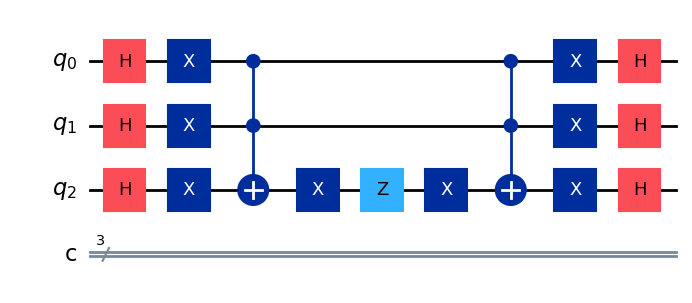

In [6]:
# Implement the Grover's algorithm

Grover = QuantumCircuit(3, 3)

Grover.h(range(3))
Grover.x(range(3))

Grover.mcx([0, 1], 2)
Grover.x(2)
Grover.z(2)
Grover.x(2)
Grover.mcx([0, 1], 2)

Grover.x(range(3))
Grover.h(range(3))

Grover.draw(output = 'mpl')


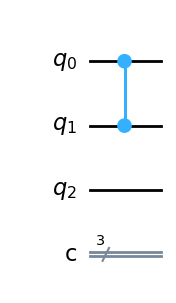

In [7]:
Detector = QuantumCircuit(3, 3)

Detector.cz(1, 0)
Detector.draw(output = 'mpl')

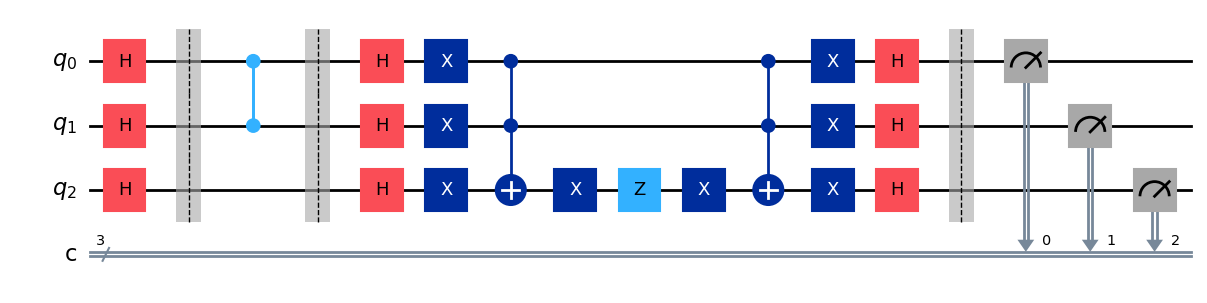

In [9]:
circ = QuantumCircuit(3, 3)
circ.h(range(3))
circ.barrier(range(3))
circ = circ.compose(Detector)
circ.barrier(range(3))
circ = circ.compose(Grover)
circ.barrier(range(3))
circ.measure(range(3), range(3))
circ.draw(output = 'mpl')

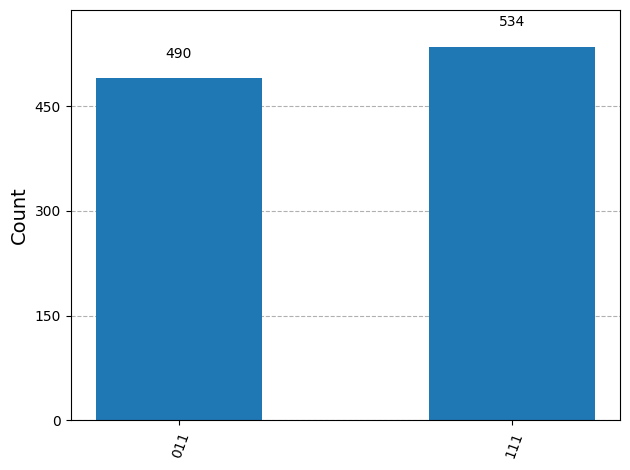

In [11]:
backend = AerSimulator()
job = backend.run(circ, shots = 1024)
result = job.result()
counts = result.get_counts()
plot_histogram(counts)